In [1]:
%load_ext autoreload
%autoreload 2
%config Completer.use_jedi = False

In [2]:
###Modules

import os
import glob
import dask
from dask.distributed import Client
import pandas as pd
import numpy as np
import re
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import matplotlib.collections as mcoll
import matplotlib.path as mpath
from matplotlib.backends.backend_pdf import PdfPages
import multiprocessing as mp
import secrets

In [2]:
### To do a linear fit on the log(dt), log(MSD) curve and define alpha and D

def get_D_alpha(traj, min_length=10, numPoints=5):
    if traj.shape[0]<min_length:
        return np.nan, np.nan, np.nan, np.nan
    model = LinearRegression()
    x = np.log10(traj.loc[traj.motion_correction_type=="corrected","time"])
    y = np.log10(traj.loc[traj.motion_correction_type=="corrected","tamsd"])
    sampleWeight = traj.loc[traj.motion_correction_type=="corrected","weight"]
    #print(x.to_numpy().reshape(-1,1)[:numPoints], y.to_numpy()[:numPoints], sampleWeight.to_numpy()[:numPoints])
    model.fit(x.to_numpy().reshape(-1,1)[:numPoints], y.to_numpy()[:numPoints], sample_weight = sampleWeight.to_numpy()[:numPoints])
    return model.intercept_, model.coef_[0], traj.induction_time.iloc[0], traj.length.iloc[0]

In [4]:
#To merge the trajectories from all the files acquired on the same day

def all_trajectories(trajectories):
    df_tmp = pd.read_csv(trajectories)
    substring = f"noaux"
    for track in df_tmp.track.unique():
        df_tmp.loc[df_tmp["track"] == track,"uniqueid"] = secrets.token_hex(8)
        if substring in trajectories:
            df_tmp["condition"] = f"noaux"
        else:
            df_tmp["condition"] = f"24h"
    return df_tmp

In [5]:
# Calculate single jumps from the trajectories

def calculate_jump(df, axis=None):
    jumps = []
    for _, sub in df.groupby("cell"):
        for _, single_traj in sub.groupby("uniqueid"):
            tvalues = single_traj["frame"].values
            tvalues = tvalues[:, None] - tvalues

            # list of lags
            lags = np.arange(10,100,10)


            # Loop over lags
            for lag in lags:
                # find indexes of pairs of timepoints with lag equal to the selected lag
                x, y = np.where(tvalues == lag)
                
                if axis is None:
                    tmp = pd.DataFrame({"jumps":np.sum(
                            np.square(
                                single_traj.iloc[x][["x", "y", "z"]].values
                                - single_traj.iloc[y][["x", "y", "z"]].values
                            ),
                            axis=1,
                        ), "frame":single_traj.iloc[y]["frame"].values})
                elif axis in ["x", "y", "z"]:
                    tmp = pd.DataFrame({"jumps":single_traj.iloc[x][axis].values - single_traj.iloc[y][axis].values, 
                                        "frame":single_traj.iloc[y]["frame"].values})
                else:
                    raise ValueError(f"axis must be in ['x', 'z', 'y'] or none, but provided {axis}")
                            
                #tmp = pd.DataFrame(tmp_jumps)
                #tmp.columns = ["jumps"]
                tmp["deltat"] = lag
                tmp["condition"] = single_traj.condition.values[0]
                jumps.append(tmp)


    return pd.concat(jumps)

In [3]:
#Paths to data

motion_corrected_path = f"/tungstenfs/scratch/ggiorget/Pia/microscopy/Rad21-Halo/motion_corrected/20221116/"
outputDir = f"/tungstenfs/scratch/ggiorget/Pia/microscopy/Rad21-Halo/MSDs/"

# Plot trajectories

### Read in the data and make one file out of all trajectories

There is a function called all_trajectories, that merges the files and cleans up a bit.
Then I define all the long trajectories and plot them, colorcoded with time.

In [6]:
results = glob.glob(f"{motion_corrected_path}*_corrected.csv")
print(results)

[]


In [7]:
with mp.Pool(min(20, len(results))) as pool:
    all_df_tmp = pool.map(all_trajectories, results)
df = pd.concat(all_df_tmp).reset_index(drop=True)
df["frame"] = df["frame"]*10
df.head()

,x,y,z,track,frame,cell,degree_av_rotation,degree_av_translation,uniqueid,condition
0,11.677947,5.236436,1.0,13190,0.0,1.0,0.020024,0.340766,cb4907f81fe72f98,24h
1,18.085845,5.217880,1.0,12721,80.0,1.0,0.020024,0.340766,d5aaa3ef50e8a618,24h
2,11.582165,5.376279,1.0,14004,80.0,1.0,0.020024,0.340766,252d119dd95b315e,24h
3,13.775436,5.796085,1.0,14005,80.0,1.0,0.020024,0.340766,abd14d583e7d2ee1,24h
4,17.852840,2.340347,1.0,14221,80.0,1.0,0.020024,0.340766,59b8e3ca0ca8cd90,24h


In [8]:
df["trLength"] = df.uniqueid.map(dict(df.groupby(by=["uniqueid"])["frame"].max()-df.groupby(by=["uniqueid"])["frame"].min()+1))

In [9]:
longTracks = df[df["trLength"] >= 1000]

In [10]:
tracks = longTracks["uniqueid"].unique()
len(tracks)

60

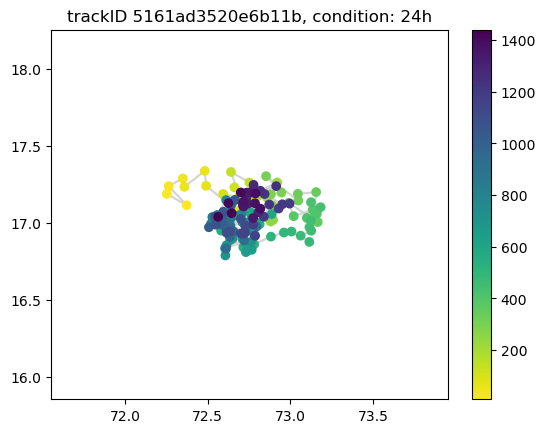

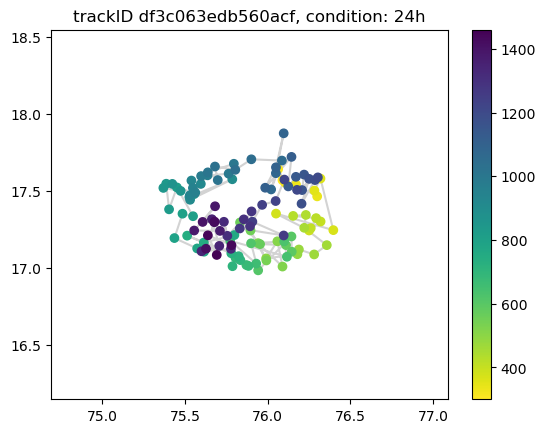

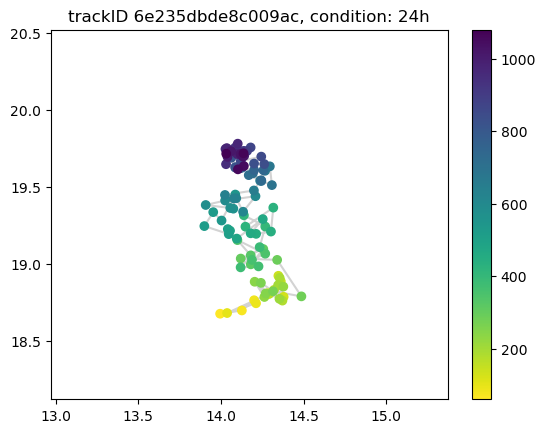

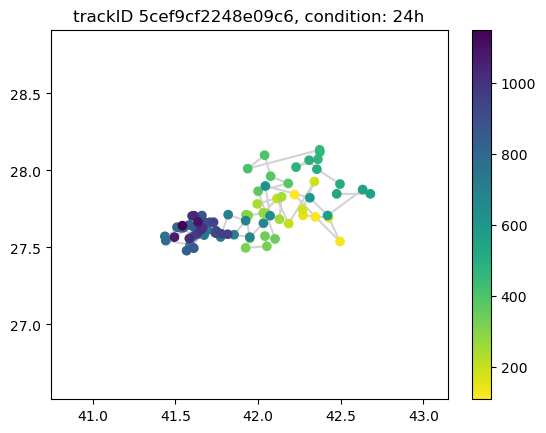

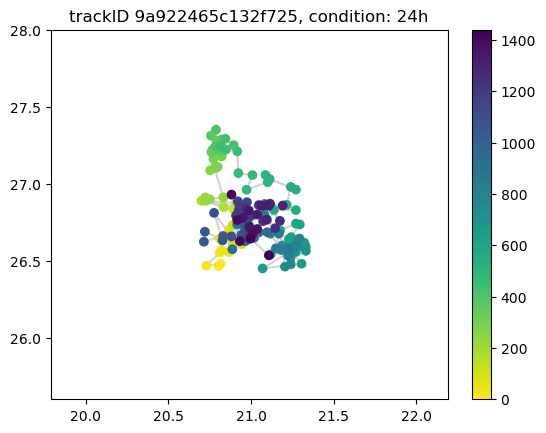

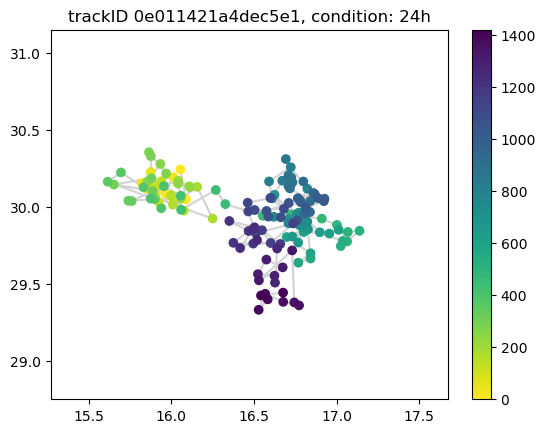

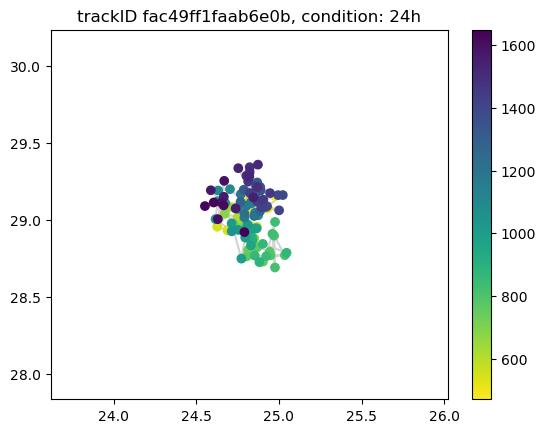

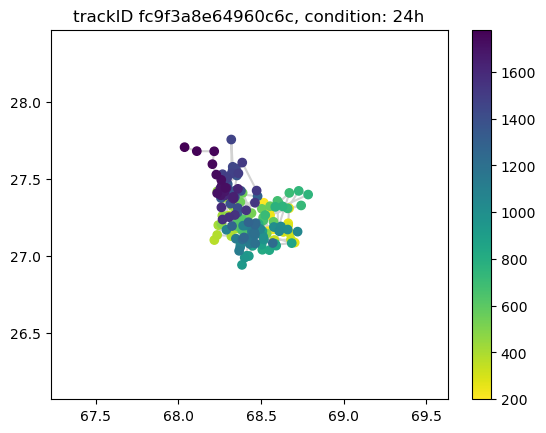

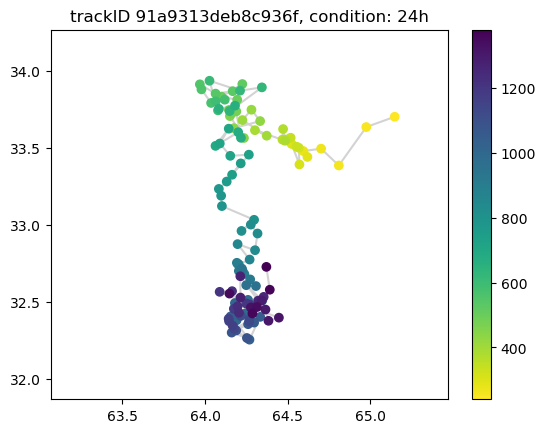

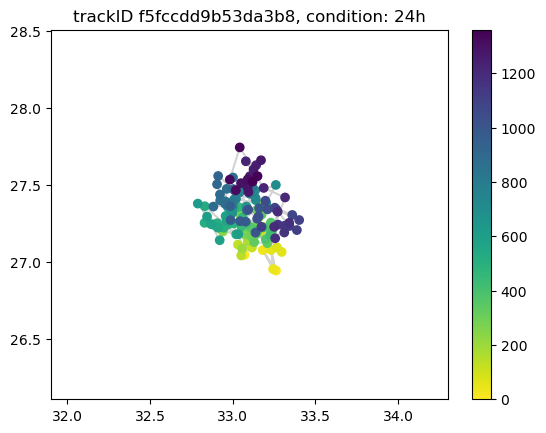

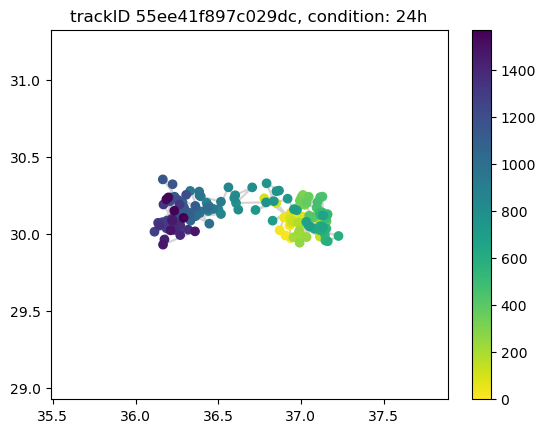

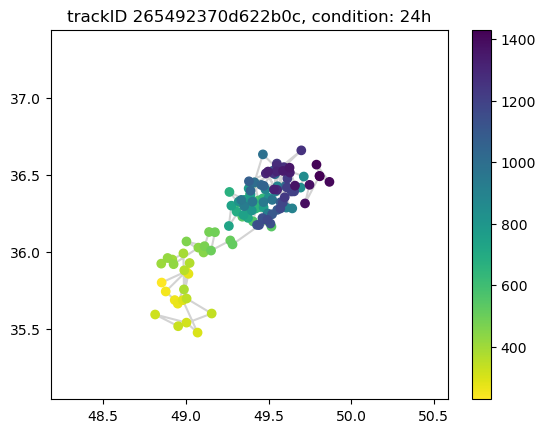

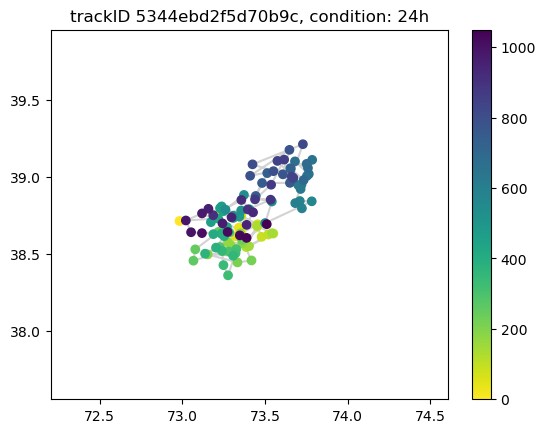

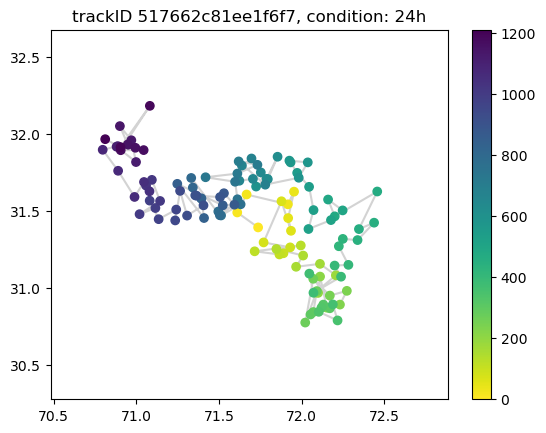

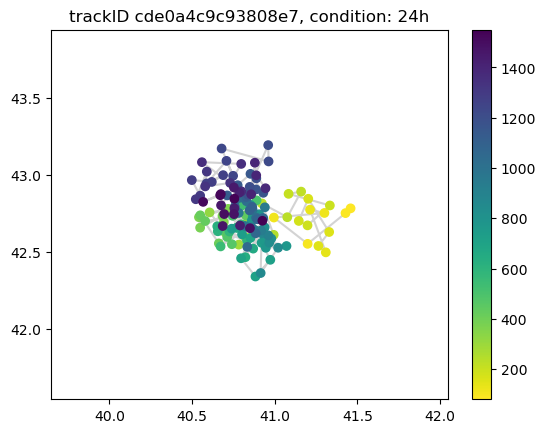

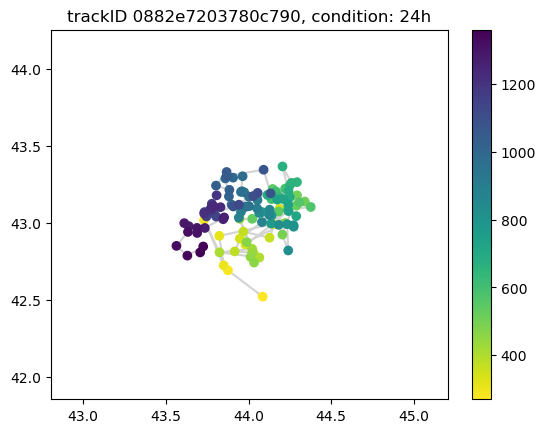

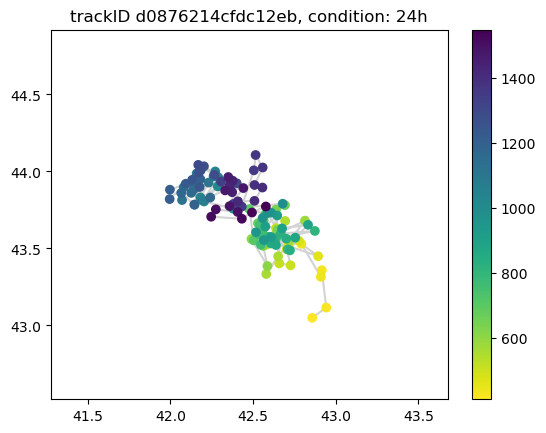

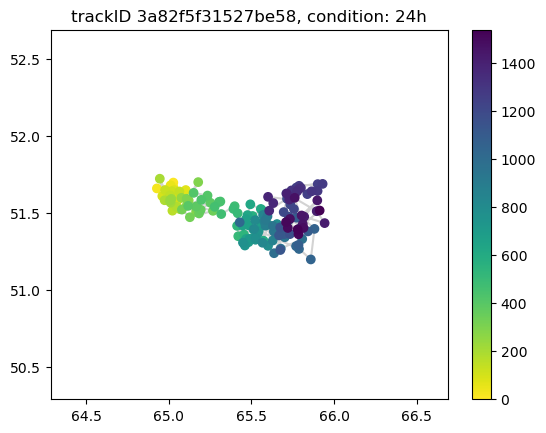

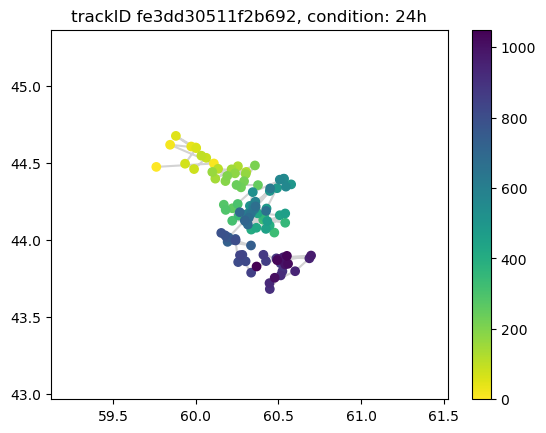

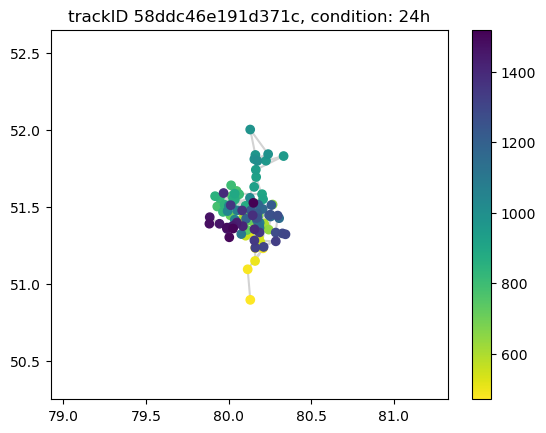

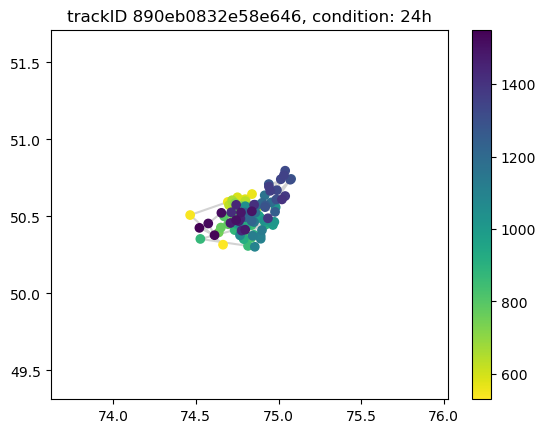

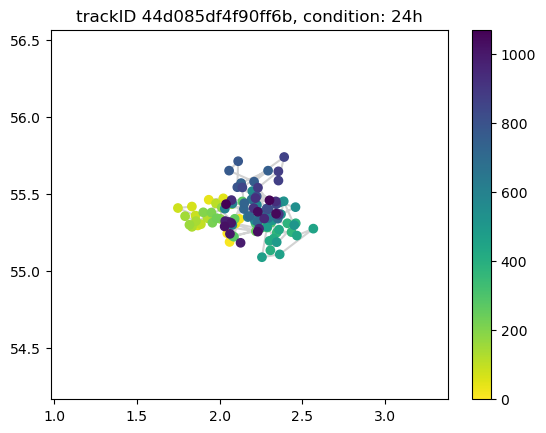

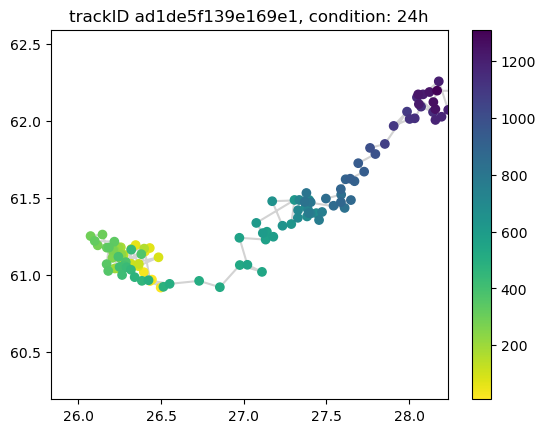

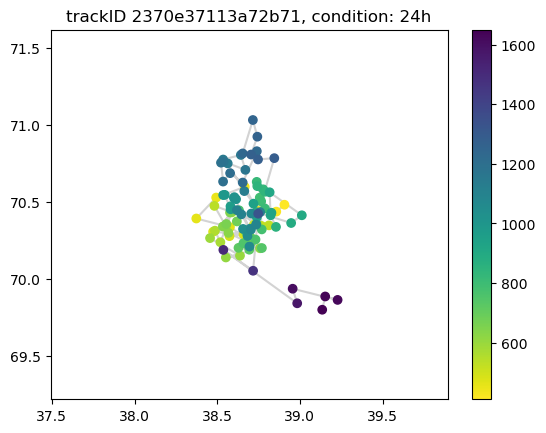

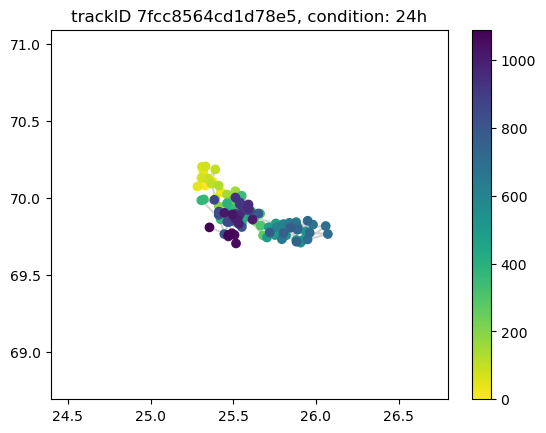

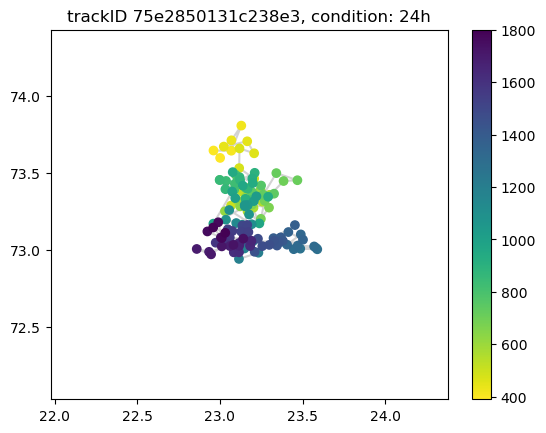

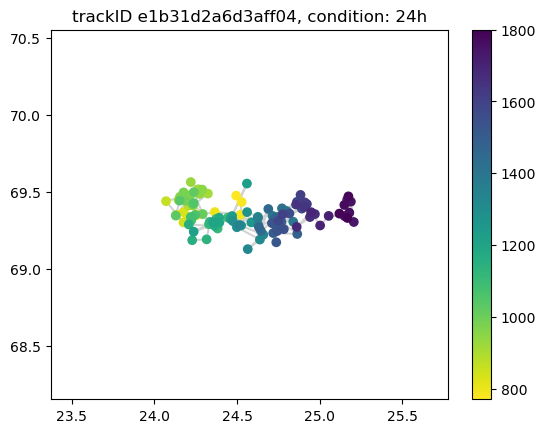

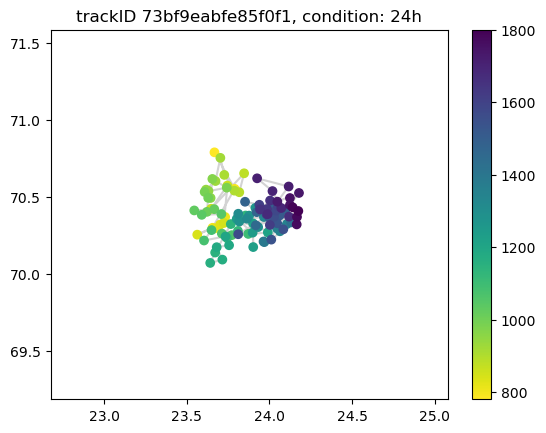

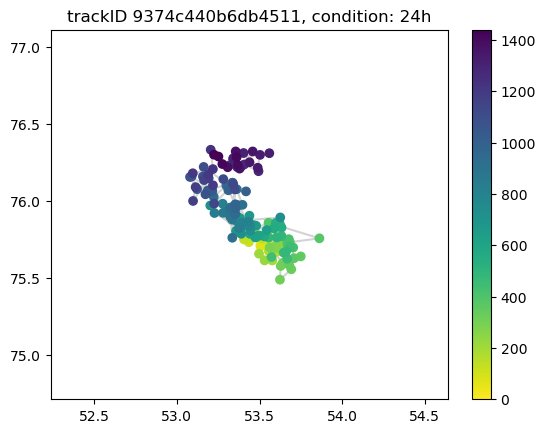

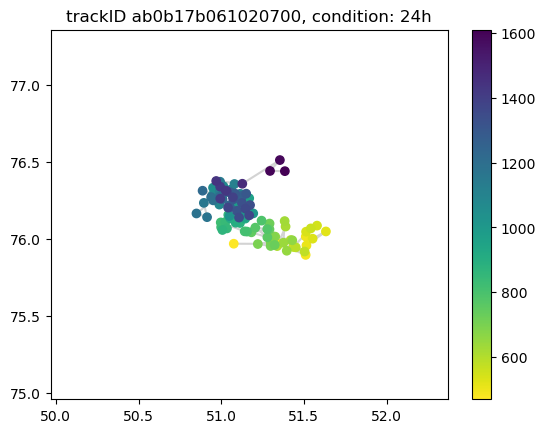

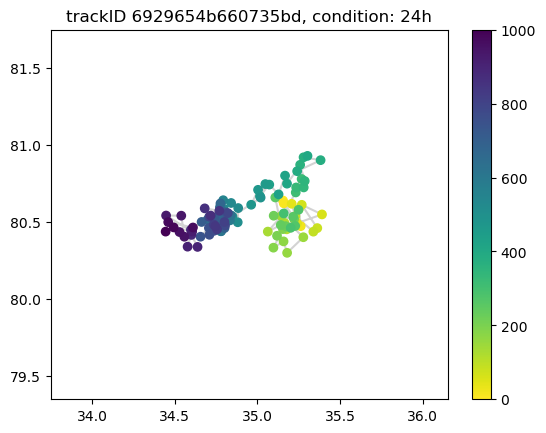

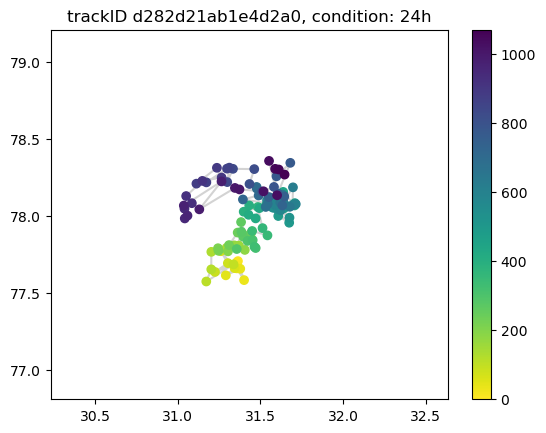

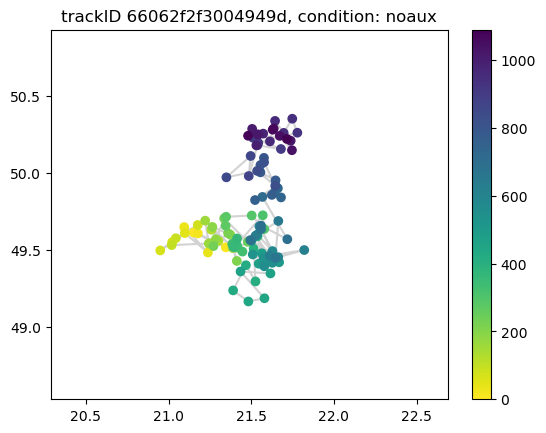

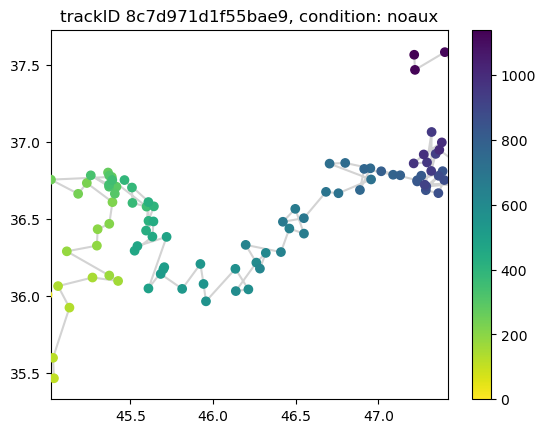

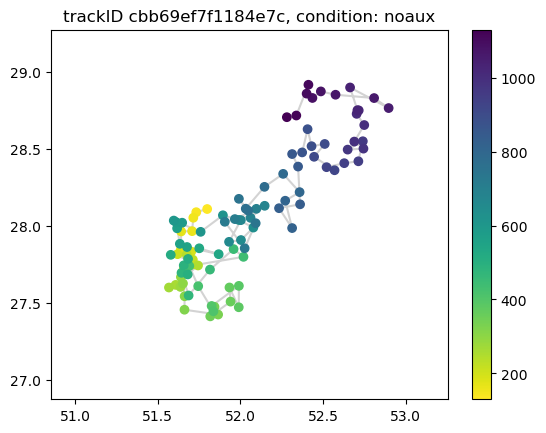

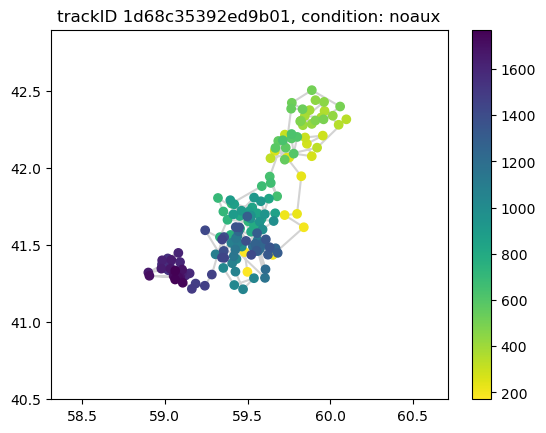

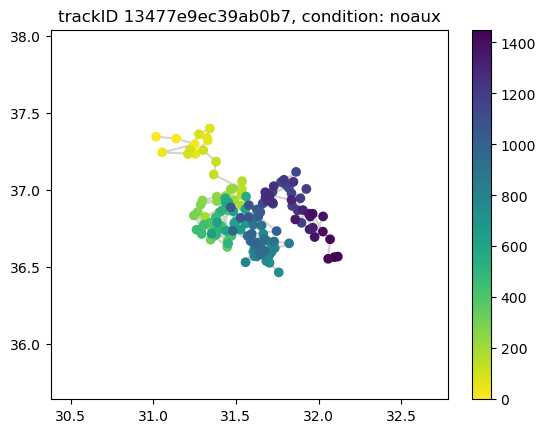

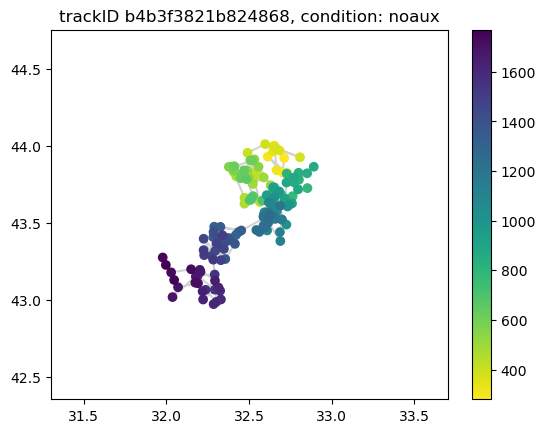

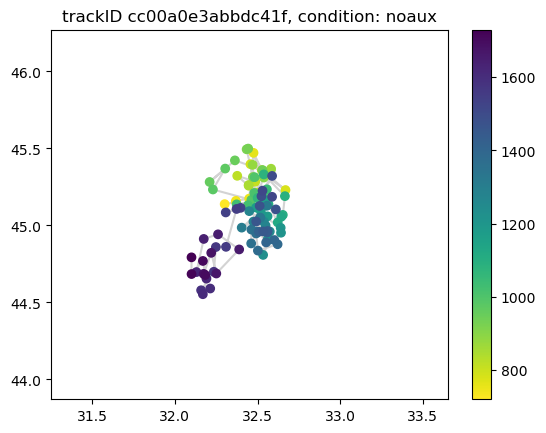

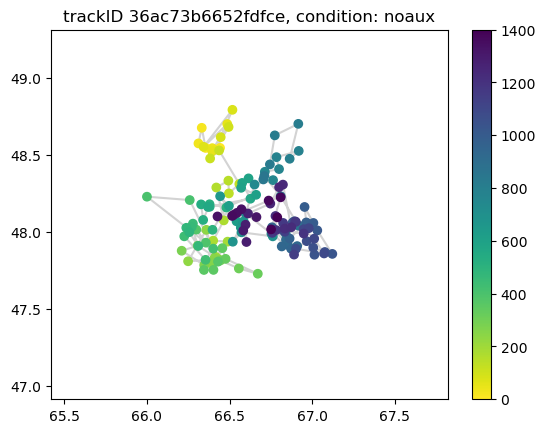

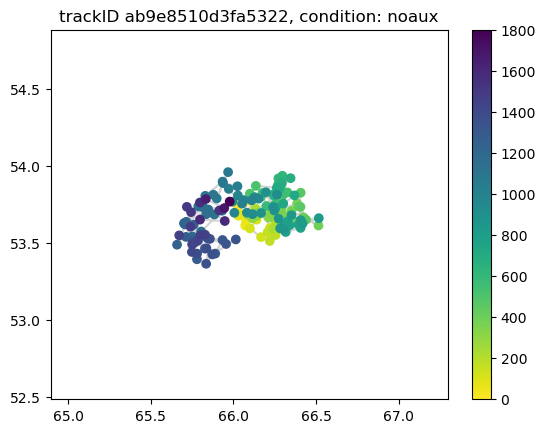

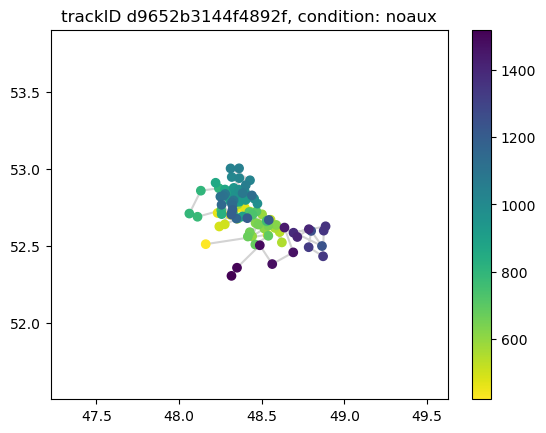

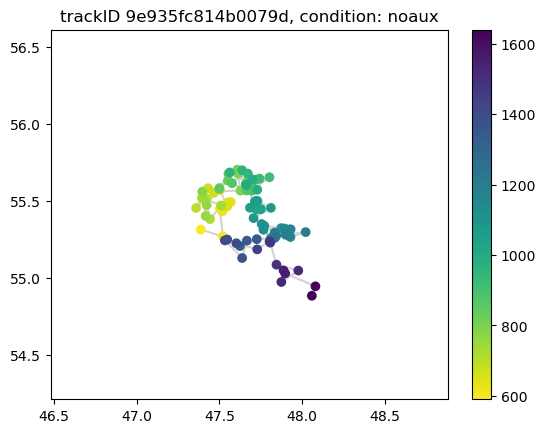

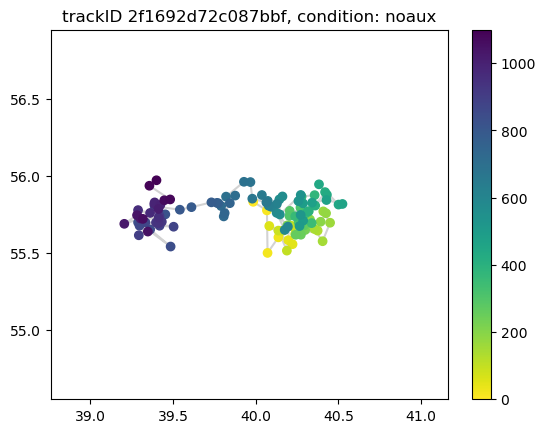

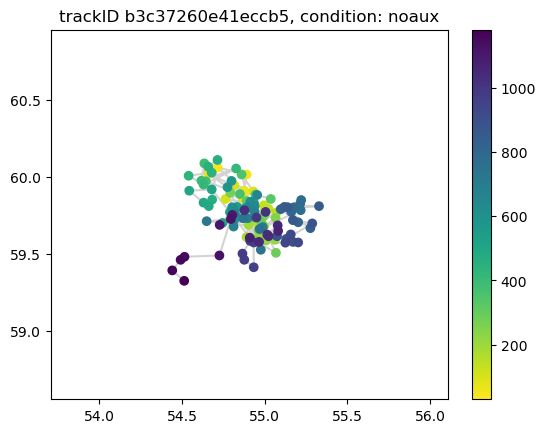

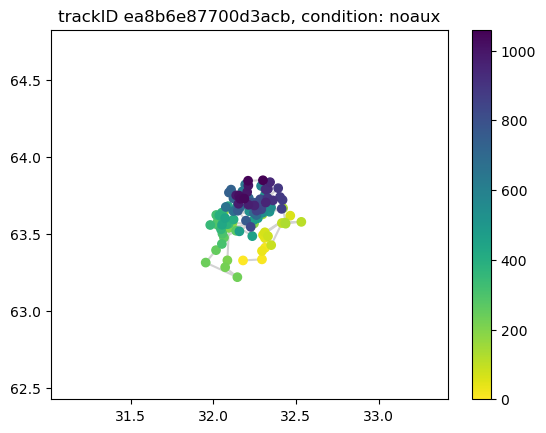

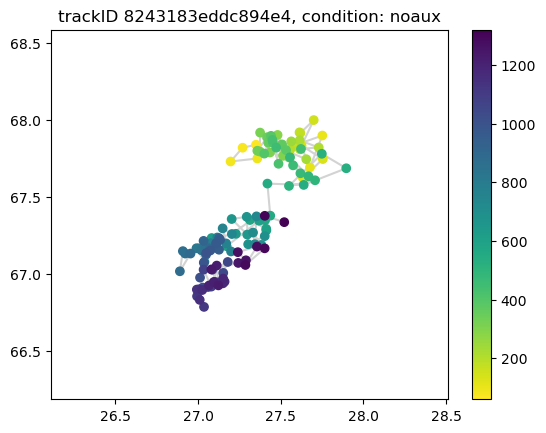

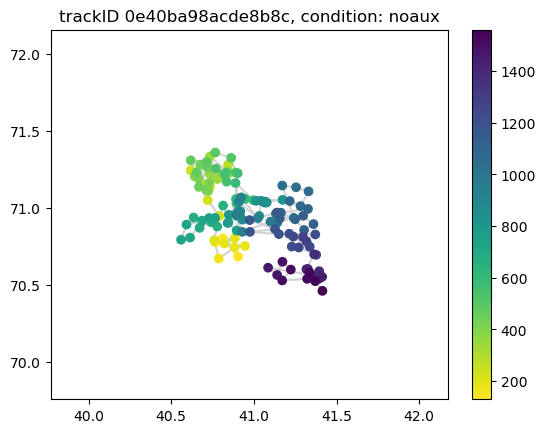

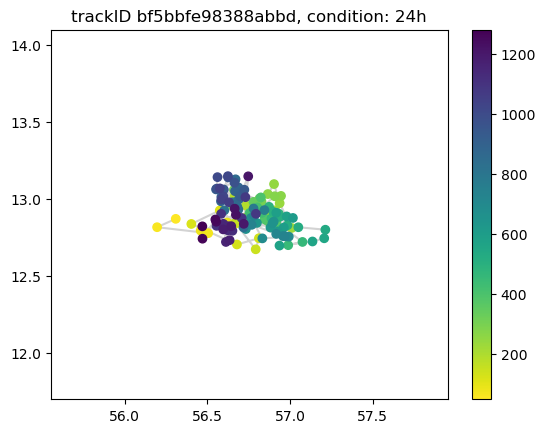

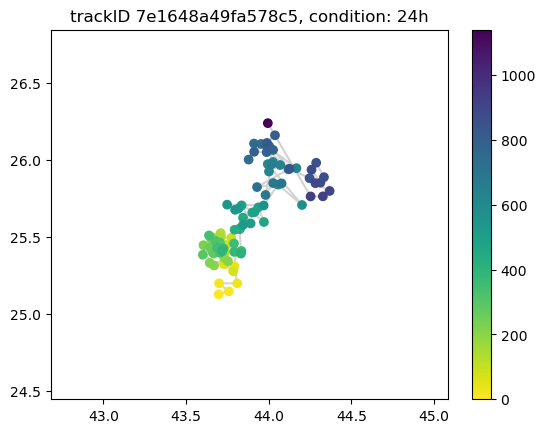

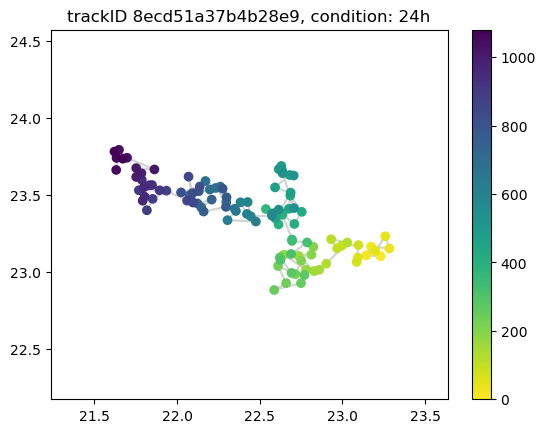

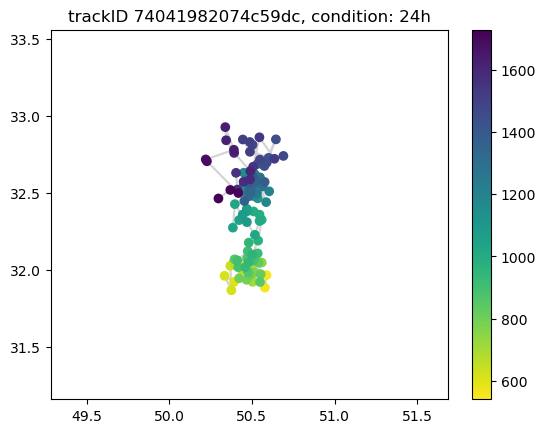

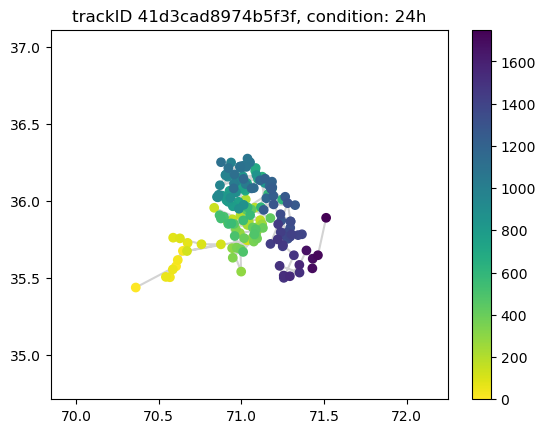

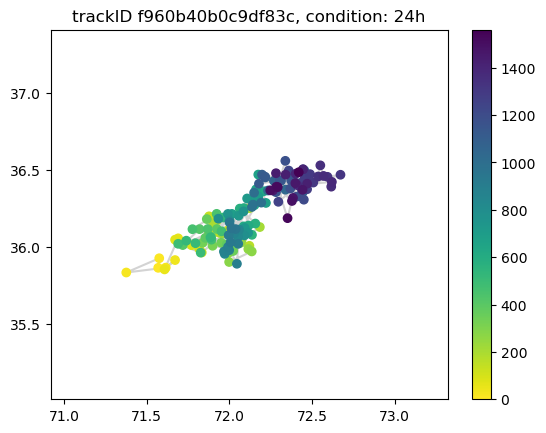

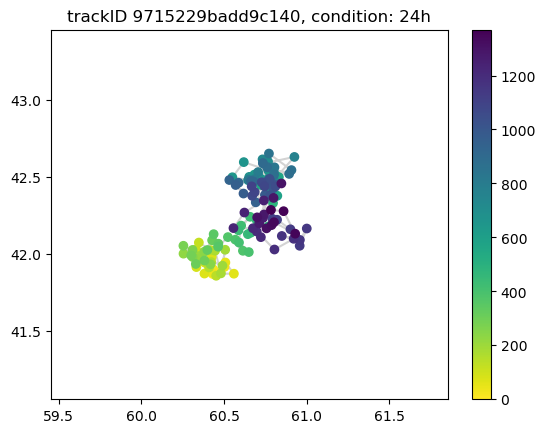

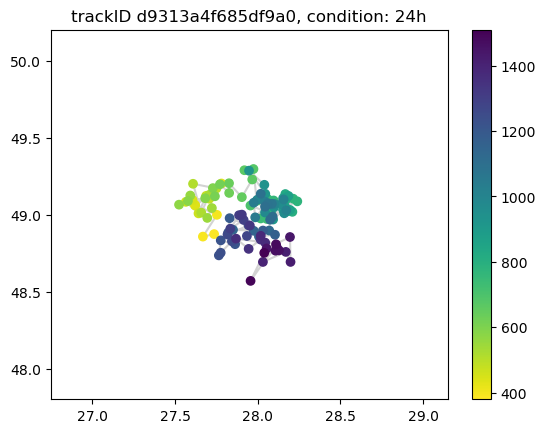

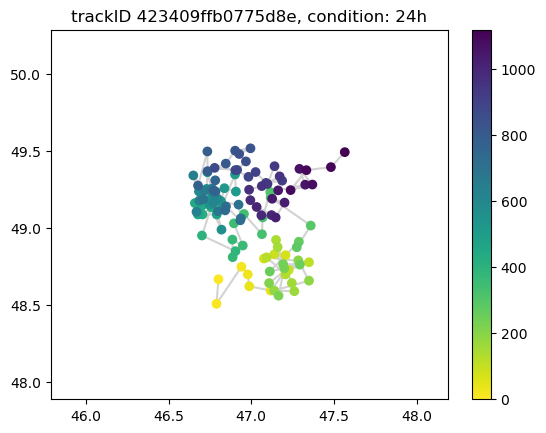

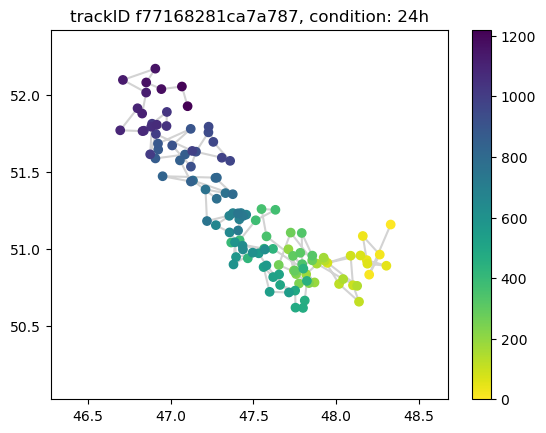

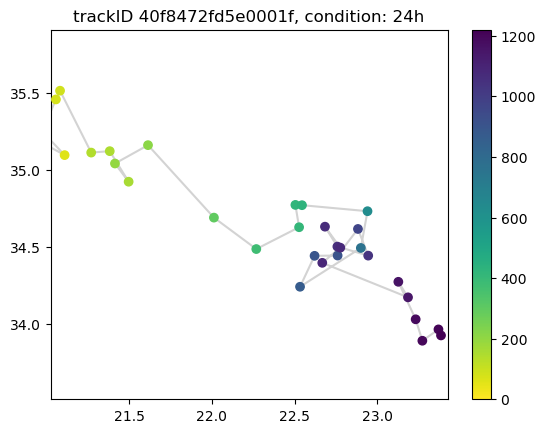

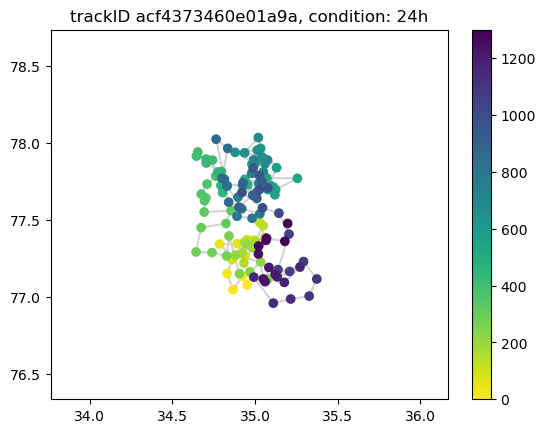

In [11]:
#This will not run for you, since you have no write permission on our tungsten. 
orig_map=plt.cm.get_cmap('viridis')
with PdfPages(f"{outputDir}NIPBL_trajectories_test.pdf") as pdf:
    for track in tracks:
        single_traj = longTracks[longTracks["uniqueid"] == track]
        plt.plot(single_traj.x, single_traj.y, c="lightgray")
        plt.scatter(single_traj.x, single_traj.y, c=single_traj.frame, zorder=15, cmap=orig_map.reversed())
        plt.xlim(single_traj.x.mean()-1.2, single_traj.x.mean()+1.2)
        plt.ylim(single_traj.y.mean()-1.2, single_traj.y.mean()+1.2)
        plt.title(f"trackID {track}, condition: {single_traj.condition.iloc[0]}")
        plt.colorbar()
        pdf.savefig()
        plt.show()
        plt.close()

# Calculate jumps

Here I take all the long trajectories (can be set to desired length in the previous section) and calculate all the jumps (so distances travelled for a specific dt) and plot the boxplots for all found displacement given a certain dt. You could also do distributions for each dt (I gave it a try).

In [12]:
jumps = calculate_jump(longTracks)
jumps

,jumps,frame,deltat,condition
0,0.015667,50.0,10,24h
1,0.096948,60.0,10,24h
2,0.002347,70.0,10,24h
3,0.028681,80.0,10,24h
4,0.002992,90.0,10,24h
...,...,...,...,...
102,0.003486,1150.0,90,24h
103,0.035313,1160.0,90,24h
104,0.072282,1170.0,90,24h
105,0.079693,1180.0,90,24h


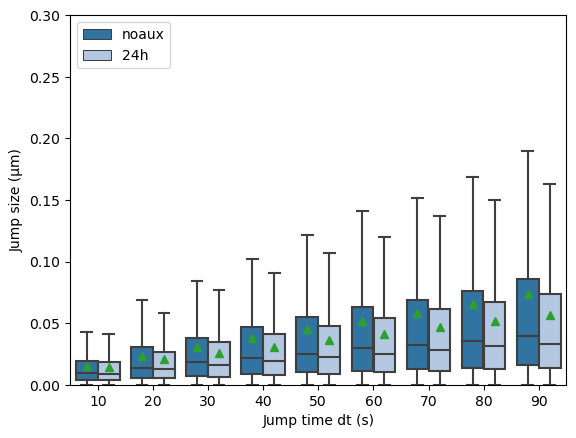

In [13]:
sns.boxplot(data=jumps, x="deltat", y="jumps", hue="condition", hue_order=["noaux","24h"], fliersize=0, palette="tab20",showmeans=True)
plt.ylim(0,0.3)
plt.xlabel("Jump time dt (s)")
plt.ylabel("Jump size (µm)")
plt.legend(loc="upper left")
plt.savefig(f"{outputDir}NIPBL_jumps_long_tracks.pdf")
plt.show()

In [14]:
jumps.groupby(["deltat","condition"]).count()

jumps  frame
deltat condition              
10     24h         5112   5112
       noaux       1901   1901
20     24h         5058   5058
       noaux       1872   1872
30     24h         5012   5012
       noaux       1862   1862
40     24h         4968   4968
       noaux       1849   1849
50     24h         4936   4936
       noaux       1835   1835
60     24h         4896   4896
       noaux       1811   1811
70     24h         4855   4855
       noaux       1798   1798
80     24h         4808   4808
       noaux       1789   1789
90     24h         4768   4768
       noaux       1768   1768

In [15]:
#And here as a histogram:
jump_dt = 10
jump_dt10 = jumps.jumps[jumps["deltat"] == jump_dt]

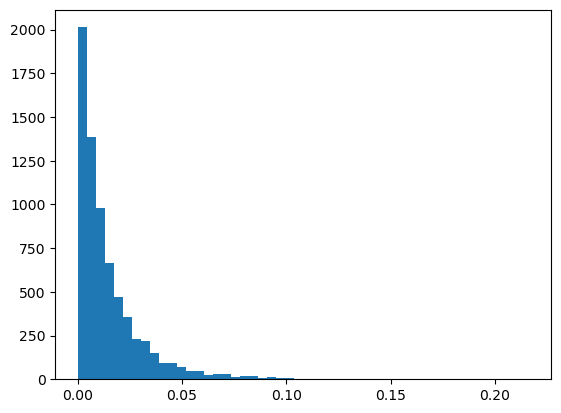

In [16]:
plt.hist(jump_dt10, bins=50);

# Plot MSDs

Here I make an average MSD plot to compare two conditions I have (noaux and 24h). 

In [17]:
msds = pd.read_csv(f"{outputDir}20221116_output.csv")
msds.lags = msds.lags*10 # to convert from frames to sec dt=10s
msds.rename(columns={'lags':'time'}, inplace=True)
msds.tamsd = msds.tamsd*1.5 # to correct for 2D vs. 3D in the MSD calculation
msds["length"] = msds.track.map(dict(msds.groupby(by="track")["time"].max()-msds.groupby(by="track")["time"].min()+10))
msds.head()

,time,tamsd,weight,cellid,uniqueid,track,trStart,traj_file,date,cell_line,degron_system,induction_time,replicate,motion_correction_type,length
0,10,0.074259,16,1.0,810ae5e19fd8d598,2103,4.0,20221116_Rad21-Halo_SPT_XXX_NIPBL_noaux_40mW_2...,20221116,XXX,NIPBL,noaux,2,uncorrected,150
1,20,0.105463,15,1.0,810ae5e19fd8d598,2103,4.0,20221116_Rad21-Halo_SPT_XXX_NIPBL_noaux_40mW_2...,20221116,XXX,NIPBL,noaux,2,uncorrected,150
2,30,0.149790,14,1.0,810ae5e19fd8d598,2103,4.0,20221116_Rad21-Halo_SPT_XXX_NIPBL_noaux_40mW_2...,20221116,XXX,NIPBL,noaux,2,uncorrected,150
3,40,0.207512,13,1.0,810ae5e19fd8d598,2103,4.0,20221116_Rad21-Halo_SPT_XXX_NIPBL_noaux_40mW_2...,20221116,XXX,NIPBL,noaux,2,uncorrected,150
4,50,0.264302,12,1.0,810ae5e19fd8d598,2103,4.0,20221116_Rad21-Halo_SPT_XXX_NIPBL_noaux_40mW_2...,20221116,XXX,NIPBL,noaux,2,uncorrected,150


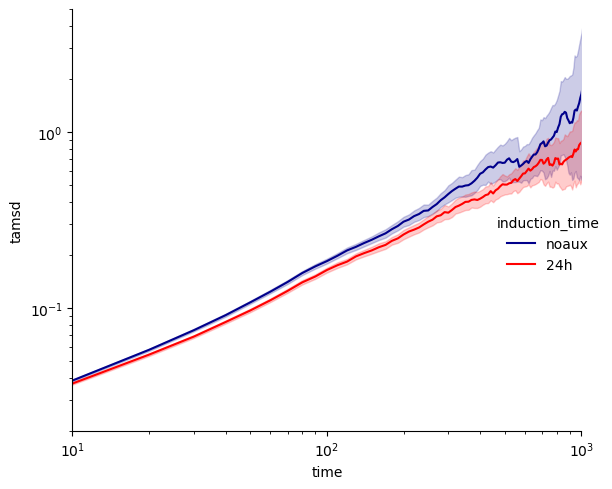

In [18]:
#This will not run properly for you, as the output folder is in our tungsten and you do not have write permissions.
sns.relplot(data=msds[(msds["motion_correction_type"] == "corrected")], x="time", y="tamsd", hue="induction_time", palette=["darkblue", "red"], kind="line")
plt.yscale("log")
plt.xscale("log")
plt.xlim(10,1000)
plt.ylim(0.02,5)
plt.tight_layout()
plt.savefig(f"{outputDir}NIPBL_MSD_test.pdf", transparent=True)
plt.show()

## Plot distributions of D (inst. diffusion coefficient) and alpha (slope, anomalous exponent)

Here I do a linear fit on the single MSDs for each trajectory based on the initial 5 points (numPoints) of the MSD for each trajectory (in log, log). So then the slope of the fitted curve is the anomalous exponent and the intersect can be interpreted as the instantaneiys diffusion coefficient (under some circumstances). Ask physicists ;)

In [19]:
minLength=10
coefficients = msds[msds["motion_correction_type"] == "corrected"].groupby(by="uniqueid").apply(get_D_alpha, min_length=minLength, numPoints=5).to_frame()

In [20]:
coefficients['D'], coefficients['alpha'], coefficients["induction"], coefficients["length"] = zip(*coefficients.iloc[:,0])
coefficients = coefficients[["D","alpha", "induction", "length"]]
coefficients.D = 10**coefficients.D
coefficients.head()

,D,alpha,induction,length
uniqueid,,,,
000d903dcf406042,0.058558,-0.012245,noaux,130.0
001cf8bb4767b7f2,0.011169,0.594726,noaux,180.0
0024a151c86c50ac,NaN,NaN,NaN,NaN
002d3f3bcfefc26d,0.017228,0.331124,24h,770.0
002e6b91731cfb4f,0.004062,0.921533,noaux,110.0


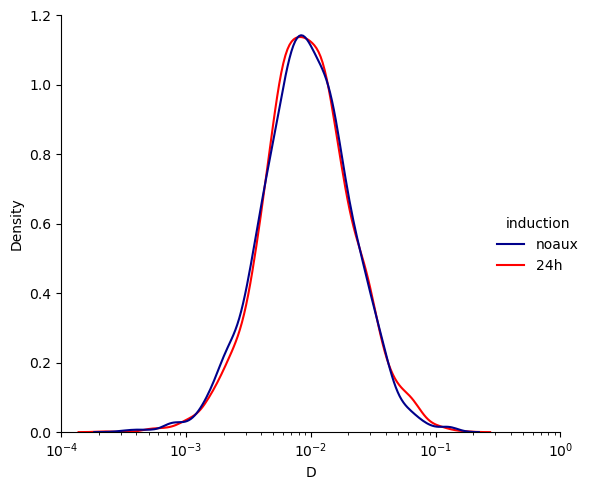

In [21]:
sns.displot(data=coefficients, x="D", log_scale=True, hue="induction", kind="kde", palette=["darkblue", "red"], common_norm=False)
#plt.xscale("log")
plt.xlim(0.0001,1)
plt.tight_layout()
plt.savefig(f"{outputDir}NIPBL_Dapp_dist_split.pdf", transparent=True)
plt.show()

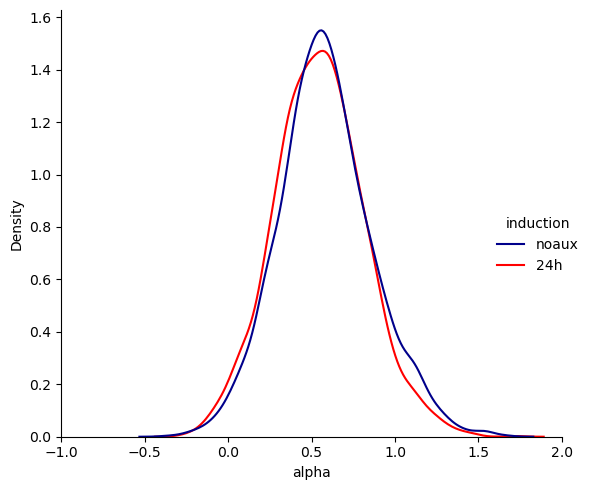

In [22]:
sns.displot(data=coefficients, x="alpha", log_scale=False, hue="induction", kind="kde", palette=["darkblue","red"], common_norm=False)
#plt.xscale("log")
plt.xlim(-1,2)
plt.tight_layout()
plt.savefig(f"{outputDir}NIPBL_alpha_dist_split.pdf", transparent=True)
plt.show()

In [23]:
coefficients.groupby(by=["induction"])[["D", "alpha"]].mean()

,D,alpha
induction,,
24h,0.013099,0.546832
noaux,0.012626,0.584017


In [24]:
coefficients.groupby(by=["induction"])[["D", "alpha"]].count()

,D,alpha
induction,,
24h,2841,2841
noaux,3262,3262
